In [5]:
"""Dataset analysis helper for UNSW-NB15.

Loads the full dataset (parts 1-4), computes basic data quality stats,
correlation pairs, mutual information scores, and proposes preprocessing
settings. Output is printed to stdout and saved as JSON so main.py can
reuse the recommendations before running the pipeline.
"""

from __future__ import annotations

import argparse
import json
from dataclasses import asdict, dataclass, field
from pathlib import Path
from typing import Dict, List, Optional, Sequence

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from preprocessing.data_loader import DataLoader


@dataclass
class AnalysisResult:
    columns_to_drop: List[str]
    categorical_columns: List[str]
    binary_columns: List[str]
    target_encoding_columns: List[str]
    onehot_encoding_columns: List[str]
    skip_scaling_columns: List[str]
    wide_range_columns: List[str]
    correlated_pairs: List[Dict[str, float]]
    correlated_to_drop: List[str]
    low_mi_features: List[str]
    mi_scores: Dict[str, float]
    thresholds: Dict[str, float]
    stats_summary: Dict[str, object]
    figure_paths: List[str] = field(default_factory=list)
    warnings: List[str] = field(default_factory=list)

    def to_json(self) -> str:
        return json.dumps(asdict(self), indent=2, default=_json_default)


def _json_default(obj):
    if isinstance(obj, (np.integer, np.int64)):
        return int(obj)
    if isinstance(obj, (np.floating, np.float64)):
        return float(obj)
    if isinstance(obj, set):
        return sorted(obj)
    if isinstance(obj, pd.DataFrame):
        return obj.to_dict(orient="list")
    if isinstance(obj, pd.Series):
        return obj.to_dict()
    return str(obj)


def _coerce_numeric(df: pd.DataFrame, min_numeric_ratio: float = 0.85) -> pd.DataFrame:
    """Convert columns to numeric when most values look numeric."""
    df = df.copy()
    for col in df.columns:
        numeric = pd.to_numeric(df[col], errors="coerce")
        if numeric.notna().mean() >= min_numeric_ratio:
            df[col] = numeric
    return df


def _get_binary_columns(df: pd.DataFrame) -> List[str]:
    binary = []
    for col in df.columns:
        uniques = df[col].dropna().unique()
        if len(uniques) <= 2:
            binary.append(col)
    return sorted(binary)


def _wide_range_columns(df: pd.DataFrame, threshold: float, skip: Sequence[str]) -> List[str]:
    cols = []
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    for col in numeric_cols:
        if col in skip:
            continue
        rng = df[col].max() - df[col].min()
        if rng > threshold:
            cols.append(col)
    return sorted(cols)


def _high_corr_pairs(df: pd.DataFrame, threshold: float) -> List[Dict[str, object]]:
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    if len(numeric_cols) < 2:
        return []
    corr = df[numeric_cols].corr().abs()
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    pairs = []
    for col in upper.columns:
        for row in upper.index:
            val = upper.loc[row, col]
            if pd.notna(val) and val > threshold:
                pairs.append({"feature_1": row, "feature_2": col, "correlation": float(val)})
    pairs = sorted(pairs, key=lambda p: p["correlation"], reverse=True)
    return pairs


def _low_mi_features(X: pd.DataFrame, y: Optional[pd.Series], threshold: float) -> List[str]:
    if y is None or threshold <= 0:
        return []
    numeric_cols = X.select_dtypes(include=[np.number]).columns
    if numeric_cols.empty:
        return []
    # Lazy import to avoid heavy SciPy load when MI is disabled
    from sklearn.feature_selection import mutual_info_classif

    X_num = X[numeric_cols].fillna(X[numeric_cols].median())
    mi_scores = mutual_info_classif(X_num, y, discrete_features=False, random_state=42)
    scores = dict(zip(numeric_cols, mi_scores))
    low = [col for col, score in scores.items() if score < threshold]
    return sorted(low)


def _mutual_info_scores(X: pd.DataFrame, y: Optional[pd.Series]) -> Dict[str, float]:
    """Return MI scores for numeric features only (safe fallback to empty)."""
    if y is None:
        return {}
    numeric_cols = X.select_dtypes(include=[np.number]).columns
    if numeric_cols.empty:
        return {}
    from sklearn.feature_selection import mutual_info_classif

    X_num = X[numeric_cols].fillna(X[numeric_cols].median())
    mi_scores = mutual_info_classif(X_num, y, discrete_features=False, random_state=42)
    return dict(zip(numeric_cols, mi_scores))


def analyze_dataset(
    data_dir: Optional[Path],
    output_dir: Path,
    input_file: Optional[Path] = None,
    sample_size: Optional[int] = 1100_000,
    missing_threshold: Optional[float] = 0.20,
    correlation_threshold: float = 0.90,
    mi_threshold: float = 0.005,
    high_cardinality_threshold: int = 100,
    wide_range_threshold: float = 1_000.0,
    preset_drop: Optional[List[str]] = None,
    generate_plots: bool = True,
) -> AnalysisResult:
    # Load data either from a single CSV (input_file) or the combined UNSW parts via DataLoader
    if input_file:
        df = pd.read_csv(input_file, nrows=sample_size)
        rows_loaded = len(df)
    else:
        loader = DataLoader(data_dir)
        loader.load_feature_catalog()
        rows_per_file = max(5_000, (sample_size or 0) // 4) if sample_size else None
        df = loader.load_combined_data(nrows=rows_per_file)
        rows_loaded = len(df)
    df.columns = df.columns.str.strip().str.lower()

    # Resolve optional thresholds
    effective_missing_threshold = 0.20 if missing_threshold is None else missing_threshold
    effective_sample_size = sample_size or len(df)

    y = None
    if "label" in df.columns:
        y = pd.to_numeric(df["label"], errors="coerce").fillna(0).astype(int)
    X = df.drop(columns=["label", "attack_cat"], errors="ignore")

    X = _coerce_numeric(X)

    missing_pct = X.isnull().mean()
    drop_missing = missing_pct[missing_pct > effective_missing_threshold].index.tolist()
    constants = [c for c in X.columns if X[c].nunique(dropna=False) <= 1]

    columns_to_drop = sorted(set((preset_drop or []) + drop_missing + constants))

    # Cardinality and type suggestions
    categorical_columns = sorted([c for c in X.columns if X[c].dtype == object])
    binary_columns = _get_binary_columns(X)
    high_cardinality = [c for c in categorical_columns if X[c].nunique(dropna=True) > high_cardinality_threshold]
    onehot_columns = sorted([c for c in categorical_columns if c not in high_cardinality])

    # Numeric stats
    skip_for_scale = sorted(set(binary_columns))
    wide_range_cols = _wide_range_columns(X, wide_range_threshold, skip_for_scale)

    sample_n = min(effective_sample_size, len(X))
    sample_df = X.sample(n=sample_n, random_state=42) if len(X) > sample_n else X.copy()
    sample_y = y.loc[sample_df.index] if y is not None else None

    corr_pairs = _high_corr_pairs(sample_df, correlation_threshold)
    correlated_to_drop = sorted({p["feature_1"] for p in corr_pairs} | {p["feature_2"] for p in corr_pairs})

    mi_scores = _mutual_info_scores(sample_df, sample_y)
    low_mi = sorted([col for col, score in mi_scores.items() if score < mi_threshold]) if mi_scores else []

    stats_summary = {
        "rows_sampled": int(rows_loaded),
        "cols_before": int(df.shape[1]),
        "cols_after_drop": int(X.shape[1] - len(columns_to_drop)),
        "missing_over_threshold": columns_to_drop,
        "wide_range_columns": wide_range_cols,
        "binary_columns": binary_columns,
        "categorical_columns": categorical_columns,
        "high_cardinality_categoricals": high_cardinality,
        "corr_pairs_count": len(corr_pairs),
        "low_mi_count": len(low_mi),
        "sample_size_used": int(sample_n),
        "rows_loaded": int(rows_loaded),
    }

    warnings: List[str] = []
    if not corr_pairs:
        warnings.append("No correlated feature pairs above threshold.")
    if not low_mi:
        warnings.append("No low-MI numeric features under the given threshold.")
    if wide_range_cols:
        warnings.append("Scaling suggested for wide-range numeric columns.")

    result = AnalysisResult(
        columns_to_drop=columns_to_drop,
        categorical_columns=categorical_columns,
        binary_columns=binary_columns,
        target_encoding_columns=sorted(high_cardinality),
        onehot_encoding_columns=onehot_columns,
        skip_scaling_columns=skip_for_scale,
        wide_range_columns=wide_range_cols,
        correlated_pairs=corr_pairs,
        correlated_to_drop=correlated_to_drop,
        low_mi_features=low_mi,
        mi_scores=mi_scores,
        thresholds={
            "missing_threshold": effective_missing_threshold,
            "correlation_threshold": correlation_threshold,
            "mi_threshold": mi_threshold,
            "wide_range_threshold": wide_range_threshold,
        },
        stats_summary=stats_summary,
        warnings=warnings,
    )

    output_dir.mkdir(parents=True, exist_ok=True)
    report_path = output_dir / "analyzer_report.json"
    report_path.write_text(result.to_json())
    print(f"Analyzer report saved to {report_path}")

    if generate_plots:
        # Best-effort plotting (non-fatal if matplotlib fails in headless envs)
        figure_paths = _generate_figures(sample_df, sample_y, mi_scores, output_dir)
        result.figure_paths.extend([str(p) for p in figure_paths])
        print(f"Saved {len(figure_paths)} figure(s) under {output_dir / 'figures'}")

    _print_summary(result)
    return result


def _print_summary(result: AnalysisResult) -> None:
    print("\nANALYZER SUMMARY")
    s = result.stats_summary
    rows_val = s.get("rows", s.get("rows_sampled"))
    print(f"Rows: {rows_val:,}; Columns (after drop candidates): {s['cols_after_drop']}/{s['cols_before']}")
    if result.columns_to_drop:
        print(f"Drop candidates ({len(result.columns_to_drop)}): {sorted(result.columns_to_drop)}")
    if result.binary_columns:
        print(f"Binary columns ({len(result.binary_columns)}): {result.binary_columns}")
    if result.categorical_columns:
        print(f"Categorical columns ({len(result.categorical_columns)}): {result.categorical_columns}")
    if result.target_encoding_columns:
        print(f"High-cardinality target-encode: {result.target_encoding_columns}")
    if result.onehot_encoding_columns:
        print(f"One-hot encode: {result.onehot_encoding_columns}")
    if result.wide_range_columns:
        print(f"Wide-range numeric columns to scale: {result.wide_range_columns}")
    if result.correlated_pairs:
        top = result.correlated_pairs[:5]
        print(f"Top correlated pairs (threshold {result.thresholds['correlation_threshold']}):")
        for pair in top:
            print(f"  {pair['feature_1']} vs {pair['feature_2']} = {pair['correlation']:.3f}")
    if result.low_mi_features:
        print(f"Low-MI (<{result.thresholds['mi_threshold']}) numeric features: {result.low_mi_features}")
    if result.mi_scores:
        top_mi = sorted(result.mi_scores.items(), key=lambda kv: kv[1], reverse=True)[:5]
        print(f"Top MI features: {[f'{k}={v:.4f}' for k, v in top_mi]}")
    if result.figure_paths:
        print(f"Saved figures: {len(result.figure_paths)} file(s)")
    if result.warnings:
        print("Warnings:")
        for w in result.warnings:
            print(f"  - {w}")


def _generate_figures(
    sample_df: pd.DataFrame,
    sample_y: Optional[pd.Series],
    mi_scores: Dict[str, float],
    output_dir: Path,
) -> List[Path]:
    """Render a small figure set to support manual EDA."""
    figs_dir = output_dir / "figures"
    figs_dir.mkdir(parents=True, exist_ok=True)
    saved: List[Path] = []

    try:
        path = _plot_missingness(sample_df, figs_dir / "missingness.png")
        saved.append(path)
    except Exception as exc:  # noqa: BLE001
        print(f"Warning: could not create missingness plot: {exc}")

    try:
        path = _plot_correlation_heatmap(sample_df, figs_dir / "correlation_heatmap.png")
        if path:
            saved.append(path)
    except Exception as exc:  # noqa: BLE001
        print(f"Warning: could not create correlation heatmap: {exc}")

    try:
        path = _plot_mi_bar(mi_scores, figs_dir / "mi_scores.png")
        if path:
            saved.append(path)
    except Exception as exc:  # noqa: BLE001
        print(f"Warning: could not create MI plot: {exc}")

    try:
        path = _plot_class_balance(sample_y, figs_dir / "class_balance.png")
        if path:
            saved.append(path)
    except Exception as exc:  # noqa: BLE001
        print(f"Warning: could not create class balance plot: {exc}")

    try:
        path = _plot_numeric_distributions(sample_df, figs_dir / "numeric_distributions.png")
        if path:
            saved.append(path)
    except Exception as exc:  # noqa: BLE001
        print(f"Warning: could not create numeric distribution plot: {exc}")

    return saved


def _plot_missingness(df: pd.DataFrame, path: Path) -> Path:
    """Horizontal bar of top missing columns."""
    missing = df.isnull().mean().sort_values(ascending=False)
    if missing.empty:
        return path
    top = missing.head(30)
    plt.figure(figsize=(10, 6))
    top[::-1].plot(kind="barh", color="#4C72B0")
    plt.xlabel("Missing ratio")
    plt.title("Top missing columns")
    plt.tight_layout()
    plt.savefig(path, dpi=150)
    plt.close()
    return path


def _plot_correlation_heatmap(df: pd.DataFrame, path: Path, max_cols: int = 25) -> Optional[Path]:
    """Heatmap on top-variance numeric columns to highlight correlation structure."""
    numeric = df.select_dtypes(include=[np.number])
    if numeric.shape[1] < 2:
        return None
    variances = numeric.var().sort_values(ascending=False)
    cols = variances.head(max_cols).index
    corr = numeric[cols].corr()
    plt.figure(figsize=(10, 8))
    im = plt.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
    plt.colorbar(im, fraction=0.046, pad=0.04)
    plt.xticks(ticks=range(len(cols)), labels=cols, rotation=90)
    plt.yticks(ticks=range(len(cols)), labels=cols)
    plt.title("Correlation heatmap (top variance cols)")
    plt.tight_layout()
    plt.savefig(path, dpi=150)
    plt.close()
    return path


def _plot_mi_bar(mi_scores: Dict[str, float], path: Path, top_n: int = 30) -> Optional[Path]:
    """Bar chart of top mutual information features."""
    if not mi_scores:
        return None
    sorted_scores = sorted(mi_scores.items(), key=lambda kv: kv[1], reverse=True)[:top_n]
    labels, scores = zip(*sorted_scores)
    plt.figure(figsize=(10, 6))
    plt.barh(range(len(scores))[::-1], scores[::-1], color="#55A868")
    plt.yticks(range(len(labels))[::-1], labels[::-1])
    plt.xlabel("MI score")
    plt.title("Top mutual information features")
    plt.tight_layout()
    plt.savefig(path, dpi=150)
    plt.close()
    return path


def _plot_class_balance(y: Optional[pd.Series], path: Path) -> Optional[Path]:
    """Class balance bar chart for the sampled target."""
    if y is None:
        return None
    counts = y.value_counts().sort_index()
    plt.figure(figsize=(6, 4))
    counts.plot(kind="bar", color="#C44E52")
    plt.ylabel("Count")
    plt.title("Class balance")
    plt.tight_layout()
    plt.savefig(path, dpi=150)
    plt.close()
    return path


def _plot_numeric_distributions(df: pd.DataFrame, path: Path, max_cols: int = 8) -> Optional[Path]:
    """Grid of histograms for the most variable numeric columns."""
    numeric_cols = df.select_dtypes(include=[np.number])
    if numeric_cols.empty:
        return None
    variances = numeric_cols.var().sort_values(ascending=False)
    cols = variances.head(max_cols).index.tolist()
    n = len(cols)
    rows = int(np.ceil(n / 4))
    plt.figure(figsize=(12, 3 * rows))
    for idx, col in enumerate(cols, 1):
        plt.subplot(rows, 4, idx)
        series = df[col].dropna()
        plt.hist(series, bins=50, color="#8172B2", alpha=0.8)
        plt.title(col)
        plt.tight_layout()
    plt.savefig(path, dpi=150)
    plt.close()
    return path


if __name__ == "__main__":

    analyze_dataset(
        data_dir=None,  # Not used when input_file is provided
        output_dir=Path("analysis_output"),
        input_file=Path("processed_data_mc/combined_raw.csv"),
        sample_size=None,  # Use full data for analysis
        missing_threshold=None,  # Use default
        correlation_threshold=0.90,
        mi_threshold=0.005,
        high_cardinality_threshold=100,
        wide_range_threshold=1e6,
        generate_plots=True,
    )


C:\Users\shahe\AppData\Local\Temp\ipykernel_3028\4131334855.py:152: DtypeWarning: Columns (0: dsport, 1: ct_ftp_cmd, 2: attack_cat) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(input_file, nrows=sample_size)


Analyzer report saved to analysis_output\analyzer_report.json
Saved 5 figure(s) under analysis_output\figures

ANALYZER SUMMARY
Rows: 1,111,908; Columns (after drop candidates): 46/50
Drop candidates (2): ['ct_flw_http_mthd', 'is_ftp_login']
Binary columns (1): ['is_sm_ips_ports']
Categorical columns (1): ['ct_ftp_cmd']
One-hot encode: ['ct_ftp_cmd']
Wide-range numeric columns to scale: ['dbytes', 'dload', 'dtcpb', 'ltime', 'res_bdy_len', 'sbytes', 'sjit', 'sload', 'stcpb', 'stime']
Top correlated pairs (threshold 0.9):
  stime vs ltime = 1.000
  swin vs dwin = 0.997
  dloss vs dpkts = 0.992
  dbytes vs dloss = 0.992
  dbytes vs dpkts = 0.972
Low-MI (<0.005) numeric features: ['dtcpb', 'is_ftp_login', 'is_sm_ips_ports', 'stcpb']
Top MI features: ['sttl=0.3165', 'dttl=0.3002', 'swin=0.1817', 'dwin=0.1810', 'ct_dst_sport_ltm=0.1799']
Saved figures: 5 file(s)
Warnings:
  - Scaling suggested for wide-range numeric columns.


C:\Users\shahe\AppData\Local\Temp\ipykernel_3028\2714857700.py:2: DtypeWarning: Columns (0: dsport, 1: ct_ftp_cmd, 2: attack_cat) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("processed_data_mc/combined_raw.csv")


Class Distribution:

Counts:
label
0    1051800
1      60108
Name: count, dtype: int64

Percentages:
label
0    94.594157
1     5.405843
Name: proportion, dtype: float64


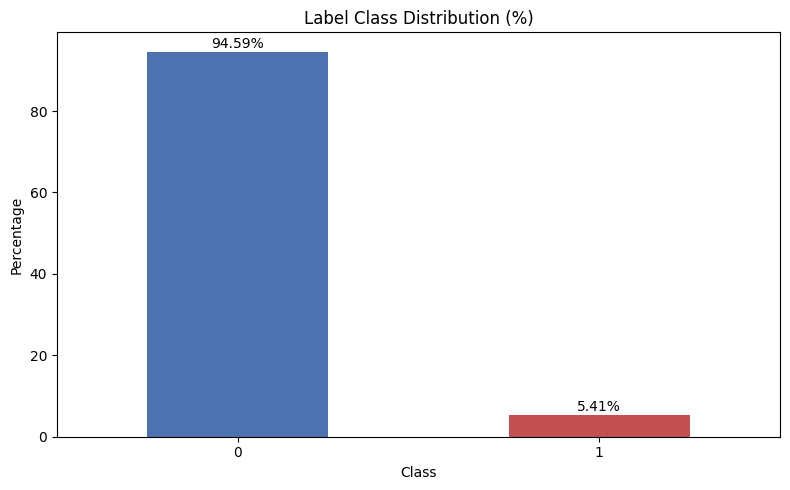

In [6]:
# Load the data
df = pd.read_csv("processed_data_mc/combined_raw.csv")

# Calculate percentage of each class in Label
label_counts = df['label'].value_counts()
label_percentages = df['label'].value_counts(normalize=True) * 100

print("Class Distribution:")
print(f"\nCounts:\n{label_counts}")
print(f"\nPercentages:\n{label_percentages}")

# Visual representation
plt.figure(figsize=(8, 5))
label_percentages.plot(kind='bar', color=['#4C72B0', '#C44E52'])
plt.title('Label Class Distribution (%)')
plt.xlabel('Class')
plt.ylabel('Percentage')
plt.xticks(rotation=0)
for i, v in enumerate(label_percentages):
    plt.text(i, v + 1, f'{v:.2f}%', ha='center')
plt.tight_layout()
plt.show()

In [8]:
"""Dataset analysis helper for UNSW-NB15.

Loads the full dataset (parts 1-4), computes basic data quality stats,
correlation pairs, mutual information scores, and proposes preprocessing
settings. Output is printed to stdout and saved as JSON so main.py can
reuse the recommendations before running the pipeline.
"""

from __future__ import annotations

import argparse
import json
from dataclasses import asdict, dataclass, field
from pathlib import Path
from typing import Dict, List, Optional, Sequence

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from preprocessing.data_loader import DataLoader


@dataclass
class AnalysisResult:
    columns_to_drop: List[str]
    categorical_columns: List[str]
    binary_columns: List[str]
    target_encoding_columns: List[str]
    onehot_encoding_columns: List[str]
    skip_scaling_columns: List[str]
    wide_range_columns: List[str]
    correlated_pairs: List[Dict[str, float]]
    correlated_to_drop: List[str]
    low_mi_features: List[str]
    mi_scores: Dict[str, float]
    thresholds: Dict[str, float]
    stats_summary: Dict[str, object]
    figure_paths: List[str] = field(default_factory=list)
    warnings: List[str] = field(default_factory=list)

    def to_json(self) -> str:
        return json.dumps(asdict(self), indent=2, default=_json_default)


def _json_default(obj):
    if isinstance(obj, (np.integer, np.int64)):
        return int(obj)
    if isinstance(obj, (np.floating, np.float64)):
        return float(obj)
    if isinstance(obj, set):
        return sorted(obj)
    if isinstance(obj, pd.DataFrame):
        return obj.to_dict(orient="list")
    if isinstance(obj, pd.Series):
        return obj.to_dict()
    return str(obj)


def _coerce_numeric(df: pd.DataFrame, min_numeric_ratio: float = 0.85) -> pd.DataFrame:
    """Convert columns to numeric when most values look numeric."""
    df = df.copy()
    for col in df.columns:
        numeric = pd.to_numeric(df[col], errors="coerce")
        if numeric.notna().mean() >= min_numeric_ratio:
            df[col] = numeric
    return df


def _get_binary_columns(df: pd.DataFrame) -> List[str]:
    binary = []
    for col in df.columns:
        uniques = df[col].dropna().unique()
        if len(uniques) <= 2:
            binary.append(col)
    return sorted(binary)


def _wide_range_columns(df: pd.DataFrame, threshold: float, skip: Sequence[str]) -> List[str]:
    cols = []
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    for col in numeric_cols:
        if col in skip:
            continue
        rng = df[col].max() - df[col].min()
        if rng > threshold:
            cols.append(col)
    return sorted(cols)


def _high_corr_pairs(df: pd.DataFrame, threshold: float) -> List[Dict[str, object]]:
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    if len(numeric_cols) < 2:
        return []
    corr = df[numeric_cols].corr().abs()
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    pairs = []
    for col in upper.columns:
        for row in upper.index:
            val = upper.loc[row, col]
            if pd.notna(val) and val > threshold:
                pairs.append({"feature_1": row, "feature_2": col, "correlation": float(val)})
    pairs = sorted(pairs, key=lambda p: p["correlation"], reverse=True)
    return pairs


def _low_mi_features(X: pd.DataFrame, y: Optional[pd.Series], threshold: float) -> List[str]:
    if y is None or threshold <= 0:
        return []
    numeric_cols = X.select_dtypes(include=[np.number]).columns
    if numeric_cols.empty:
        return []
    # Lazy import to avoid heavy SciPy load when MI is disabled
    from sklearn.feature_selection import mutual_info_classif

    X_num = X[numeric_cols].fillna(X[numeric_cols].median())
    mi_scores = mutual_info_classif(X_num, y, discrete_features=False, random_state=42)
    scores = dict(zip(numeric_cols, mi_scores))
    low = [col for col, score in scores.items() if score < threshold]
    return sorted(low)


def _mutual_info_scores(X: pd.DataFrame, y: Optional[pd.Series]) -> Dict[str, float]:
    """Return MI scores for numeric features only (safe fallback to empty)."""
    if y is None:
        return {}
    numeric_cols = X.select_dtypes(include=[np.number]).columns
    if numeric_cols.empty:
        return {}
    from sklearn.feature_selection import mutual_info_classif

    X_num = X[numeric_cols].fillna(X[numeric_cols].median())
    mi_scores = mutual_info_classif(X_num, y, discrete_features=False, random_state=42)
    return dict(zip(numeric_cols, mi_scores))


def analyze_dataset(
    data_dir: Optional[Path],
    output_dir: Path,
    input_file: Optional[Path] = None,
    sample_size: Optional[int] = 1100_000,
    missing_threshold: Optional[float] = 0.20,
    correlation_threshold: float = 0.90,
    mi_threshold: float = 0.005,
    high_cardinality_threshold: int = 100,
    wide_range_threshold: float = 1_000.0,
    preset_drop: Optional[List[str]] = None,
    generate_plots: bool = True,
) -> AnalysisResult:
    # Load data either from a single CSV (input_file) or the combined UNSW parts via DataLoader
    if input_file:
        df = pd.read_csv(input_file, nrows=sample_size)
        rows_loaded = len(df)
    else:
        loader = DataLoader(data_dir)
        loader.load_feature_catalog()
        rows_per_file = max(5_000, (sample_size or 0) // 4) if sample_size else None
        df = loader.load_combined_data(nrows=rows_per_file)
        rows_loaded = len(df)
    df.columns = df.columns.str.strip().str.lower()

    # Resolve optional thresholds
    effective_missing_threshold = 0.20 if missing_threshold is None else missing_threshold
    effective_sample_size = sample_size or len(df)

    y = None
    if "label" in df.columns:
        y = pd.to_numeric(df["label"], errors="coerce").fillna(0).astype(int)
    X = df.drop(columns=["label", "attack_cat"], errors="ignore")

    X = _coerce_numeric(X)

    missing_pct = X.isnull().mean()
    drop_missing = missing_pct[missing_pct > effective_missing_threshold].index.tolist()
    constants = [c for c in X.columns if X[c].nunique(dropna=False) <= 1]

    columns_to_drop = sorted(set((preset_drop or []) + drop_missing + constants))

    # Cardinality and type suggestions
    categorical_columns = sorted([c for c in X.columns if X[c].dtype == object])
    binary_columns = _get_binary_columns(X)
    high_cardinality = [c for c in categorical_columns if X[c].nunique(dropna=True) > high_cardinality_threshold]
    onehot_columns = sorted([c for c in categorical_columns if c not in high_cardinality])

    # Numeric stats
    skip_for_scale = sorted(set(binary_columns))
    wide_range_cols = _wide_range_columns(X, wide_range_threshold, skip_for_scale)

    sample_n = min(effective_sample_size, len(X))
    sample_df = X.sample(n=sample_n, random_state=42) if len(X) > sample_n else X.copy()
    sample_y = y.loc[sample_df.index] if y is not None else None

    corr_pairs = _high_corr_pairs(sample_df, correlation_threshold)
    correlated_to_drop = sorted({p["feature_1"] for p in corr_pairs} | {p["feature_2"] for p in corr_pairs})

    mi_scores = _mutual_info_scores(sample_df, sample_y)
    low_mi = sorted([col for col, score in mi_scores.items() if score < mi_threshold]) if mi_scores else []

    stats_summary = {
        "rows_sampled": int(rows_loaded),
        "cols_before": int(df.shape[1]),
        "cols_after_drop": int(X.shape[1] - len(columns_to_drop)),
        "missing_over_threshold": columns_to_drop,
        "wide_range_columns": wide_range_cols,
        "binary_columns": binary_columns,
        "categorical_columns": categorical_columns,
        "high_cardinality_categoricals": high_cardinality,
        "corr_pairs_count": len(corr_pairs),
        "low_mi_count": len(low_mi),
        "sample_size_used": int(sample_n),
        "rows_loaded": int(rows_loaded),
    }

    warnings: List[str] = []
    if not corr_pairs:
        warnings.append("No correlated feature pairs above threshold.")
    if not low_mi:
        warnings.append("No low-MI numeric features under the given threshold.")
    if wide_range_cols:
        warnings.append("Scaling suggested for wide-range numeric columns.")

    result = AnalysisResult(
        columns_to_drop=columns_to_drop,
        categorical_columns=categorical_columns,
        binary_columns=binary_columns,
        target_encoding_columns=sorted(high_cardinality),
        onehot_encoding_columns=onehot_columns,
        skip_scaling_columns=skip_for_scale,
        wide_range_columns=wide_range_cols,
        correlated_pairs=corr_pairs,
        correlated_to_drop=correlated_to_drop,
        low_mi_features=low_mi,
        mi_scores=mi_scores,
        thresholds={
            "missing_threshold": effective_missing_threshold,
            "correlation_threshold": correlation_threshold,
            "mi_threshold": mi_threshold,
            "wide_range_threshold": wide_range_threshold,
        },
        stats_summary=stats_summary,
        warnings=warnings,
    )

    output_dir.mkdir(parents=True, exist_ok=True)
    report_path = output_dir / "analyzer_report.json"
    report_path.write_text(result.to_json())
    print(f"Analyzer report saved to {report_path}")

    if generate_plots:
        # Best-effort plotting (non-fatal if matplotlib fails in headless envs)
        figure_paths = _generate_figures(sample_df, sample_y, mi_scores, output_dir)
        result.figure_paths.extend([str(p) for p in figure_paths])
        print(f"Saved {len(figure_paths)} figure(s) under {output_dir / 'figures'}")

    _print_summary(result)
    return result


def _print_summary(result: AnalysisResult) -> None:
    print("\nANALYZER SUMMARY")
    s = result.stats_summary
    rows_val = s.get("rows", s.get("rows_sampled"))
    print(f"Rows: {rows_val:,}; Columns (after drop candidates): {s['cols_after_drop']}/{s['cols_before']}")
    if result.columns_to_drop:
        print(f"Drop candidates ({len(result.columns_to_drop)}): {sorted(result.columns_to_drop)}")
    if result.binary_columns:
        print(f"Binary columns ({len(result.binary_columns)}): {result.binary_columns}")
    if result.categorical_columns:
        print(f"Categorical columns ({len(result.categorical_columns)}): {result.categorical_columns}")
    if result.target_encoding_columns:
        print(f"High-cardinality target-encode: {result.target_encoding_columns}")
    if result.onehot_encoding_columns:
        print(f"One-hot encode: {result.onehot_encoding_columns}")
    if result.wide_range_columns:
        print(f"Wide-range numeric columns to scale: {result.wide_range_columns}")
    if result.correlated_pairs:
        top = result.correlated_pairs[:5]
        print(f"Top correlated pairs (threshold {result.thresholds['correlation_threshold']}):")
        for pair in top:
            print(f"  {pair['feature_1']} vs {pair['feature_2']} = {pair['correlation']:.3f}")
    if result.low_mi_features:
        print(f"Low-MI (<{result.thresholds['mi_threshold']}) numeric features: {result.low_mi_features}")
    if result.mi_scores:
        top_mi = sorted(result.mi_scores.items(), key=lambda kv: kv[1], reverse=True)[:5]
        print(f"Top MI features: {[f'{k}={v:.4f}' for k, v in top_mi]}")
    if result.figure_paths:
        print(f"Saved figures: {len(result.figure_paths)} file(s)")
    if result.warnings:
        print("Warnings:")
        for w in result.warnings:
            print(f"  - {w}")


def _generate_figures(
    sample_df: pd.DataFrame,
    sample_y: Optional[pd.Series],
    mi_scores: Dict[str, float],
    output_dir: Path,
) -> List[Path]:
    """Render a small figure set to support manual EDA."""
    figs_dir = output_dir / "figures"
    figs_dir.mkdir(parents=True, exist_ok=True)
    saved: List[Path] = []

    try:
        path = _plot_missingness(sample_df, figs_dir / "missingness.png")
        saved.append(path)
    except Exception as exc:  # noqa: BLE001
        print(f"Warning: could not create missingness plot: {exc}")

    try:
        path = _plot_correlation_heatmap(sample_df, figs_dir / "correlation_heatmap.png")
        if path:
            saved.append(path)
    except Exception as exc:  # noqa: BLE001
        print(f"Warning: could not create correlation heatmap: {exc}")

    try:
        path = _plot_mi_bar(mi_scores, figs_dir / "mi_scores.png")
        if path:
            saved.append(path)
    except Exception as exc:  # noqa: BLE001
        print(f"Warning: could not create MI plot: {exc}")

    try:
        path = _plot_class_balance(sample_y, figs_dir / "class_balance.png")
        if path:
            saved.append(path)
    except Exception as exc:  # noqa: BLE001
        print(f"Warning: could not create class balance plot: {exc}")

    try:
        path = _plot_numeric_distributions(sample_df, figs_dir / "numeric_distributions.png")
        if path:
            saved.append(path)
    except Exception as exc:  # noqa: BLE001
        print(f"Warning: could not create numeric distribution plot: {exc}")

    return saved


def _plot_missingness(df: pd.DataFrame, path: Path) -> Path:
    """Horizontal bar of top missing columns."""
    missing = df.isnull().mean().sort_values(ascending=False)
    if missing.empty:
        return path
    top = missing.head(30)
    plt.figure(figsize=(10, 6))
    top[::-1].plot(kind="barh", color="#4C72B0")
    plt.xlabel("Missing ratio")
    plt.title("Top missing columns")
    plt.tight_layout()
    plt.savefig(path, dpi=150)
    plt.close()
    return path


def _plot_correlation_heatmap(df: pd.DataFrame, path: Path, max_cols: int = 25) -> Optional[Path]:
    """Heatmap on top-variance numeric columns to highlight correlation structure."""
    numeric = df.select_dtypes(include=[np.number])
    if numeric.shape[1] < 2:
        return None
    variances = numeric.var().sort_values(ascending=False)
    cols = variances.head(max_cols).index
    corr = numeric[cols].corr()
    plt.figure(figsize=(10, 8))
    im = plt.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
    plt.colorbar(im, fraction=0.046, pad=0.04)
    plt.xticks(ticks=range(len(cols)), labels=cols, rotation=90)
    plt.yticks(ticks=range(len(cols)), labels=cols)
    plt.title("Correlation heatmap (top variance cols)")
    plt.tight_layout()
    plt.savefig(path, dpi=150)
    plt.close()
    return path


def _plot_mi_bar(mi_scores: Dict[str, float], path: Path, top_n: int = 30) -> Optional[Path]:
    """Bar chart of top mutual information features."""
    if not mi_scores:
        return None
    sorted_scores = sorted(mi_scores.items(), key=lambda kv: kv[1], reverse=True)[:top_n]
    labels, scores = zip(*sorted_scores)
    plt.figure(figsize=(10, 6))
    plt.barh(range(len(scores))[::-1], scores[::-1], color="#55A868")
    plt.yticks(range(len(labels))[::-1], labels[::-1])
    plt.xlabel("MI score")
    plt.title("Top mutual information features")
    plt.tight_layout()
    plt.savefig(path, dpi=150)
    plt.close()
    return path


def _plot_class_balance(y: Optional[pd.Series], path: Path) -> Optional[Path]:
    """Class balance bar chart for the sampled target."""
    if y is None:
        return None
    counts = y.value_counts().sort_index()
    plt.figure(figsize=(6, 4))
    counts.plot(kind="bar", color="#C44E52")
    plt.ylabel("Count")
    plt.title("Class balance")
    plt.tight_layout()
    plt.savefig(path, dpi=150)
    plt.close()
    return path


def _plot_numeric_distributions(df: pd.DataFrame, path: Path, max_cols: int = 8) -> Optional[Path]:
    """Grid of histograms for the most variable numeric columns."""
    numeric_cols = df.select_dtypes(include=[np.number])
    if numeric_cols.empty:
        return None
    variances = numeric_cols.var().sort_values(ascending=False)
    cols = variances.head(max_cols).index.tolist()
    n = len(cols)
    rows = int(np.ceil(n / 4))
    plt.figure(figsize=(12, 3 * rows))
    for idx, col in enumerate(cols, 1):
        plt.subplot(rows, 4, idx)
        series = df[col].dropna()
        plt.hist(series, bins=50, color="#8172B2", alpha=0.8)
        plt.title(col)
        plt.tight_layout()
    plt.savefig(path, dpi=150)
    plt.close()
    return path


if __name__ == "__main__":

    analyze_dataset(
        data_dir=None,  # Not used when input_file is provided
        output_dir=Path("analysis_output"),
        input_file=Path("processed_data_mc/combined_raw12.csv"),
        sample_size=None,  # Use full data for analysis
        missing_threshold=None,  # Use default
        correlation_threshold=0.90,
        mi_threshold=0.005,
        high_cardinality_threshold=100,
        wide_range_threshold=1e6,
        generate_plots=True,
    )


C:\Users\shahe\AppData\Local\Temp\ipykernel_3028\4276485693.py:152: DtypeWarning: Columns (0: sport, 1: dsport, 2: ct_ftp_cmd, 3: attack_cat) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(input_file, nrows=sample_size)


Analyzer report saved to analysis_output\analyzer_report.json
Saved 5 figure(s) under analysis_output\figures

ANALYZER SUMMARY
Rows: 1,277,539; Columns (after drop candidates): 48/50
Binary columns (1): ['is_sm_ips_ports']
Categorical columns (1): ['ct_ftp_cmd']
One-hot encode: ['ct_ftp_cmd']
Wide-range numeric columns to scale: ['dbytes', 'dload', 'dtcpb', 'ltime', 'res_bdy_len', 'sbytes', 'sjit', 'sload', 'stcpb', 'stime']
Top correlated pairs (threshold 0.9):
  stime vs ltime = 1.000
  swin vs dwin = 0.998
  dloss vs dpkts = 0.993
  dbytes vs dloss = 0.991
  dbytes vs dpkts = 0.971
Low-MI (<0.005) numeric features: ['ct_flw_http_mthd', 'dtcpb', 'is_ftp_login', 'is_sm_ips_ports', 'stcpb']
Top MI features: ['sttl=0.2859', 'dttl=0.2770', 'ct_dst_sport_ltm=0.2520', 'swin=0.1973', 'dwin=0.1973']
Saved figures: 5 file(s)
Warnings:
  - Scaling suggested for wide-range numeric columns.


C:\Users\shahe\AppData\Local\Temp\ipykernel_3028\4112245439.py:2: DtypeWarning: Columns (0: sport, 1: dsport, 2: ct_ftp_cmd, 3: attack_cat) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("processed_data_mc/combined_raw12.csv")


Class Distribution:

Counts:
label
0    1242441
1      35098
Name: count, dtype: int64

Percentages:
label
0    97.252687
1     2.747313
Name: proportion, dtype: float64


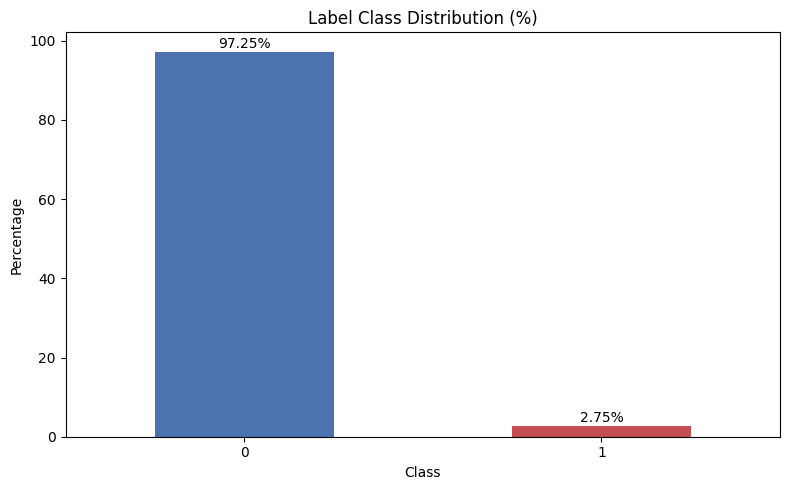

In [10]:
# Load the data
df = pd.read_csv("processed_data_mc/combined_raw12.csv")

# Calculate percentage of each class in Label
label_counts = df['label'].value_counts()
label_percentages = df['label'].value_counts(normalize=True) * 100

print("Class Distribution:")
print(f"\nCounts:\n{label_counts}")
print(f"\nPercentages:\n{label_percentages}")

# Visual representation
plt.figure(figsize=(8, 5))
label_percentages.plot(kind='bar', color=['#4C72B0', '#C44E52'])
plt.title('Label Class Distribution (%)')
plt.xlabel('Class')
plt.ylabel('Percentage')
plt.xticks(rotation=0)
for i, v in enumerate(label_percentages):
    plt.text(i, v + 1, f'{v:.2f}%', ha='center')
plt.tight_layout()
plt.show()

C:\Users\shahe\AppData\Local\Temp\ipykernel_3028\3938384306.py:2: DtypeWarning: Columns (0: sport, 1: dsport, 2: ct_ftp_cmd, 3: attack_cat) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("processed_data_mc/combined_raw13.csv")


Class Distribution:

Counts:
label
0    1062378
1      53566
Name: count, dtype: int64

Percentages:
label
0    95.199938
1     4.800062
Name: proportion, dtype: float64


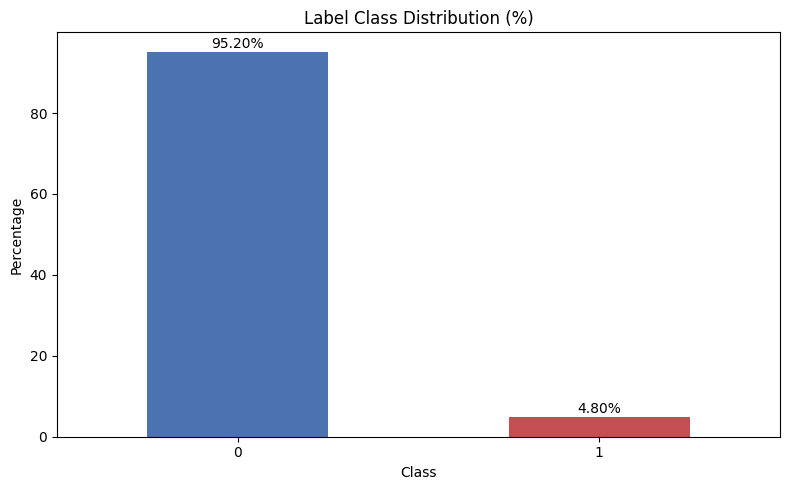

In [11]:
# Load the data
df = pd.read_csv("processed_data_mc/combined_raw13.csv")

# Calculate percentage of each class in Label
label_counts = df['label'].value_counts()
label_percentages = df['label'].value_counts(normalize=True) * 100

print("Class Distribution:")
print(f"\nCounts:\n{label_counts}")
print(f"\nPercentages:\n{label_percentages}")

# Visual representation
plt.figure(figsize=(8, 5))
label_percentages.plot(kind='bar', color=['#4C72B0', '#C44E52'])
plt.title('Label Class Distribution (%)')
plt.xlabel('Class')
plt.ylabel('Percentage')
plt.xticks(rotation=0)
for i, v in enumerate(label_percentages):
    plt.text(i, v + 1, f'{v:.2f}%', ha='center')
plt.tight_layout()
plt.show()

C:\Users\shahe\AppData\Local\Temp\ipykernel_3028\618358390.py:2: DtypeWarning: Columns (0: sport, 1: dsport, 2: ct_ftp_cmd, 3: attack_cat) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("processed_data_mc/combined_raw14.csv")


Class Distribution:

Counts:
target_mc
Normal              907970
Exploits             10893
Generic               9727
 Fuzzers              4970
 Fuzzers              3991
 Reconnaissance       3420
DoS                   2290
Reconnaissance        1740
Analysis               922
Backdoor               623
 Shellcode             371
Backdoors              299
Shellcode              223
Worms                   66
Name: count, dtype: int64

Percentages:
target_mc
Normal              95.827463
Exploits             1.149651
Generic              1.026591
 Fuzzers             0.524535
 Fuzzers             0.421211
 Reconnaissance      0.360948
DoS                  0.241687
Reconnaissance       0.183640
Analysis             0.097308
Backdoor             0.065752
 Shellcode           0.039155
Backdoors            0.031557
Shellcode            0.023535
Worms                0.006966
Name: proportion, dtype: float64


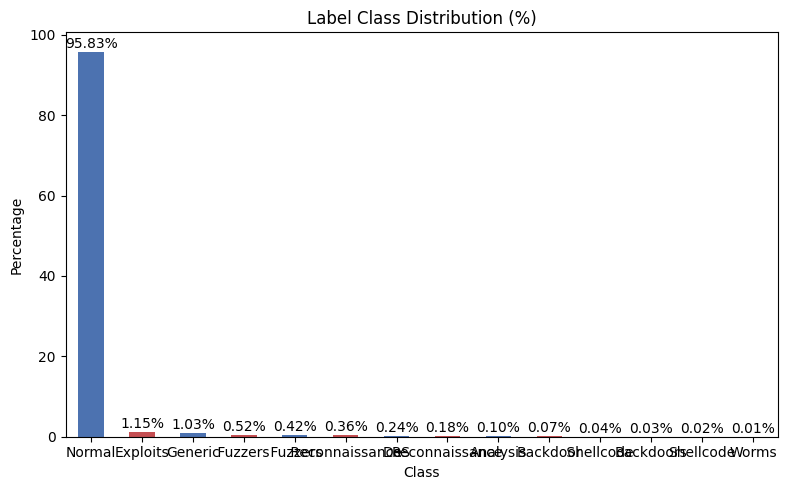

In [22]:
# Load the data
df = pd.read_csv("processed_data_mc/combined_raw14.csv")

# Calculate percentage of each class in Label
label_counts = df['target_mc'].value_counts()
label_percentages = df['target_mc'].value_counts(normalize=True) * 100

print("Class Distribution:")
print(f"\nCounts:\n{label_counts}")
print(f"\nPercentages:\n{label_percentages}")

# Visual representation
plt.figure(figsize=(8, 5))
label_percentages.plot(kind='bar', color=['#4C72B0', '#C44E52'])
plt.title('Label Class Distribution (%)')
plt.xlabel('Class')
plt.ylabel('Percentage')
plt.xticks(rotation=0)
for i, v in enumerate(label_percentages):
    plt.text(i, v + 1, f'{v:.2f}%', ha='center')
plt.tight_layout()
plt.show()

Class Distribution:

Counts:
target_mc
Normal              717330
Generic              17743
Exploits             17501
 Fuzzers             13463
 Reconnaissance       8600
DoS                   3502
Backdoor              1340
Analysis              1325
 Shellcode             964
Worms                  107
Name: count, dtype: int64

Percentages:
target_mc
Normal              91.744844
Generic              2.269289
Exploits             2.238337
 Fuzzers             1.721886
 Reconnaissance      1.099920
DoS                  0.447898
Backdoor             0.171383
Analysis             0.169464
 Shellcode           0.123293
Worms                0.013685
Name: proportion, dtype: float64


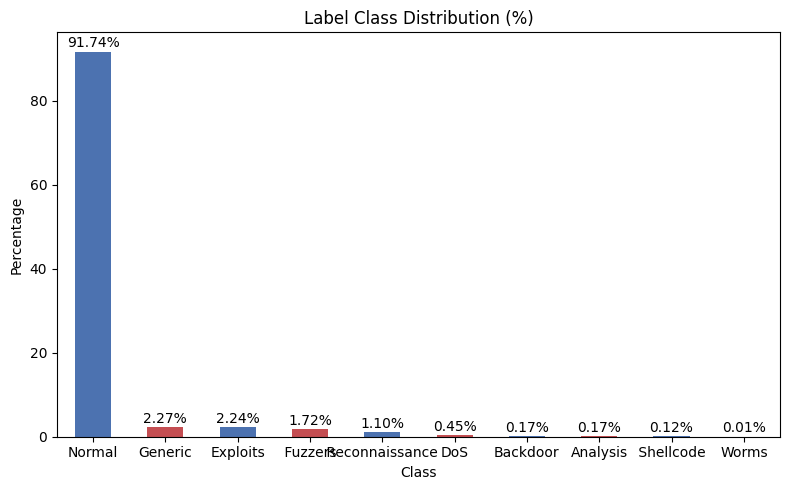

In [21]:
# Load the data
df = pd.read_csv("processed_data_mc/combined_raw34.csv")

# Calculate percentage of each class in Label
label_counts = df['target_mc'].value_counts()
label_percentages = df['target_mc'].value_counts(normalize=True) * 100

print("Class Distribution:")
print(f"\nCounts:\n{label_counts}")
print(f"\nPercentages:\n{label_percentages}")

# Visual representation
plt.figure(figsize=(8, 5))
label_percentages.plot(kind='bar', color=['#4C72B0', '#C44E52'])
plt.title('Label Class Distribution (%)')
plt.xlabel('Class')
plt.ylabel('Percentage')
plt.xticks(rotation=0)
for i, v in enumerate(label_percentages):
    plt.text(i, v + 1, f'{v:.2f}%', ha='center')
plt.tight_layout()
plt.show()

C:\Users\shahe\AppData\Local\Temp\ipykernel_3028\3920412638.py:2: DtypeWarning: Columns (0: dsport, 1: ct_ftp_cmd, 2: attack_cat) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("processed_data_mc/combined_raw234.csv")


Class Distribution:

Counts:
target_mc
Normal              1333261
Exploits              23557
Generic               22545
 Fuzzers              17804
 Reconnaissance       11617
DoS                    4840
Analysis               1883
Backdoor               1684
 Shellcode             1288
Worms                   147
Name: count, dtype: int64

Percentages:
target_mc
Normal              93.982558
Exploits             1.660550
Generic              1.589214
 Fuzzers             1.255017
 Reconnaissance      0.818891
DoS                  0.341175
Analysis             0.132734
Backdoor             0.118706
 Shellcode           0.090792
Worms                0.010362
Name: proportion, dtype: float64


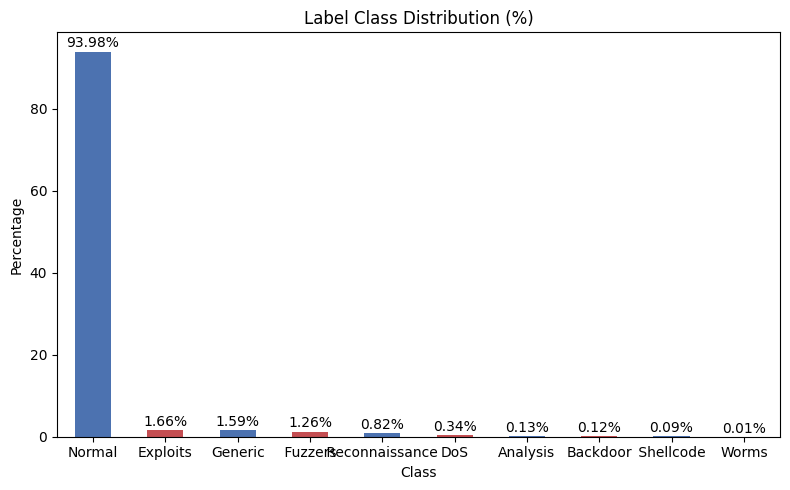

In [20]:
# Load the data
df = pd.read_csv("processed_data_mc/combined_raw234.csv")

# Calculate percentage of each class in Label
label_counts = df['target_mc'].value_counts()
label_percentages = df['target_mc'].value_counts(normalize=True) * 100

print("Class Distribution:")
print(f"\nCounts:\n{label_counts}")
print(f"\nPercentages:\n{label_percentages}")

# Visual representation
plt.figure(figsize=(8, 5))
label_percentages.plot(kind='bar', color=['#4C72B0', '#C44E52'])
plt.title('Label Class Distribution (%)')
plt.xlabel('Class')
plt.ylabel('Percentage')
plt.xticks(rotation=0)
for i, v in enumerate(label_percentages):
    plt.text(i, v + 1, f'{v:.2f}%', ha='center')
plt.tight_layout()
plt.show()

C:\Users\shahe\AppData\Local\Temp\ipykernel_3028\2792673970.py:2: DtypeWarning: Columns (0: sport, 1: dsport, 2: ct_ftp_cmd, 3: attack_cat) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("processed_data_mc/combined_raw1234.csv")


Class Distribution:

Counts:
target_mc
Normal              1959770
Exploits              27599
Generic               25378
 Fuzzers              17804
 Reconnaissance       11617
DoS                    5665
 Fuzzers               3991
Analysis               2184
Reconnaissance         1740
Backdoor               1684
 Shellcode             1288
Backdoors               299
Shellcode               223
Worms                   171
Name: count, dtype: int64

Percentages:
target_mc
Normal              95.161582
Exploits             1.340139
Generic              1.232293
 Fuzzers             0.864518
 Reconnaissance      0.564093
DoS                  0.275078
 Fuzzers             0.193793
Analysis             0.106050
Reconnaissance       0.084490
Backdoor             0.081771
 Shellcode           0.062542
Backdoors            0.014519
Shellcode            0.010828
Worms                0.008303
Name: proportion, dtype: float64


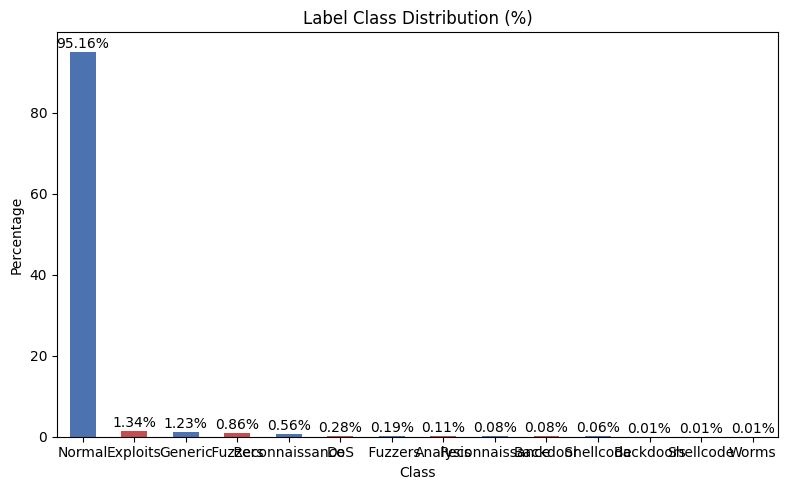

In [19]:
# Load the data
df = pd.read_csv("processed_data_mc/combined_raw1234.csv")

# Calculate percentage of each class in Label
label_counts = df['target_mc'].value_counts()
label_percentages = df['target_mc'].value_counts(normalize=True) * 100

print("Class Distribution:")
print(f"\nCounts:\n{label_counts}")
print(f"\nPercentages:\n{label_percentages}")

# Visual representation
plt.figure(figsize=(8, 5))
label_percentages.plot(kind='bar', color=['#4C72B0', '#C44E52'])
plt.title('Label Class Distribution (%)')
plt.xlabel('Class')
plt.ylabel('Percentage')
plt.xticks(rotation=0)
for i, v in enumerate(label_percentages):
    plt.text(i, v + 1, f'{v:.2f}%', ha='center')
plt.tight_layout()
plt.show()

In [18]:
df.head()

,srcip,sport,dstip,dsport,proto,state,dur,sbytes,dbytes,sttl,...,ct_srv_src,ct_srv_dst,ct_dst_ltm,ct_src_ ltm,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,attack_cat,label,target_mc
0,59.166.0.0,33661,149.171.126.9,1024,udp,CON,0.036133,528,304,31,...,2,4,2,3,1,1,2,NaN,0,Normal
1,59.166.0.6,1464,149.171.126.7,53,udp,CON,0.001119,146,178,31,...,12,8,1,2,2,1,1,NaN,0,Normal
2,59.166.0.5,3593,149.171.126.5,53,udp,CON,0.001209,132,164,31,...,6,9,1,1,1,1,1,NaN,0,Normal
3,59.166.0.3,49664,149.171.126.0,53,udp,CON,0.001169,146,178,31,...,7,9,1,1,1,1,1,NaN,0,Normal
4,59.166.0.0,32119,149.171.126.9,111,udp,CON,0.078339,568,312,31,...,2,4,2,3,1,1,2,NaN,0,Normal


Class Distribution:

Counts:
label
1    119341
0     56000
Name: count, dtype: int64

Percentages:
label
1    68.062233
0    31.937767
Name: proportion, dtype: float64


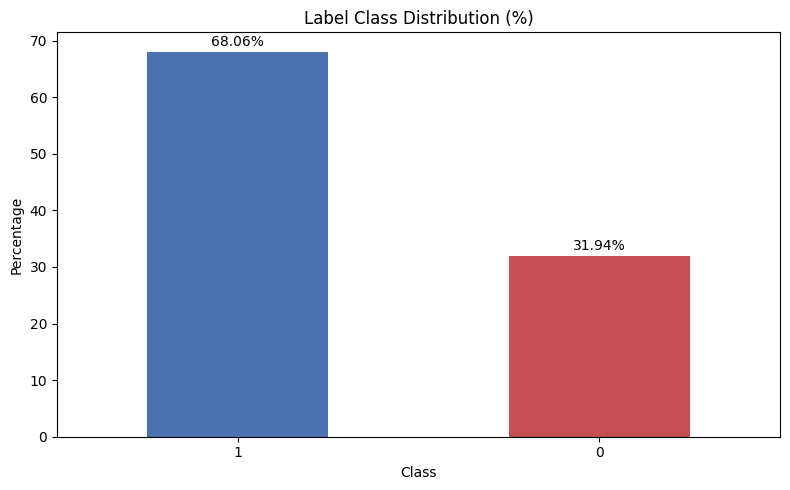

In [25]:
# Load the data
df = pd.read_csv("D:\\VS_CODE\\Python\\AI_Lab\\data\\UNSW_NB15_training-set.csv")

# Calculate percentage of each class in Label
label_counts = df['label'].value_counts()
label_percentages = df['label'].value_counts(normalize=True) * 100

print("Class Distribution:")
print(f"\nCounts:\n{label_counts}")
print(f"\nPercentages:\n{label_percentages}")

# Visual representation
plt.figure(figsize=(8, 5))
label_percentages.plot(kind='bar', color=['#4C72B0', '#C44E52'])
plt.title('Label Class Distribution (%)')
plt.xlabel('Class')
plt.ylabel('Percentage')
plt.xticks(rotation=0)
for i, v in enumerate(label_percentages):
    plt.text(i, v + 1, f'{v:.2f}%', ha='center')
plt.tight_layout()
plt.show()

Class Distribution:

Counts:
label
1    45332
0    37000
Name: count, dtype: int64

Percentages:
label
1    55.060001
0    44.939999
Name: proportion, dtype: float64


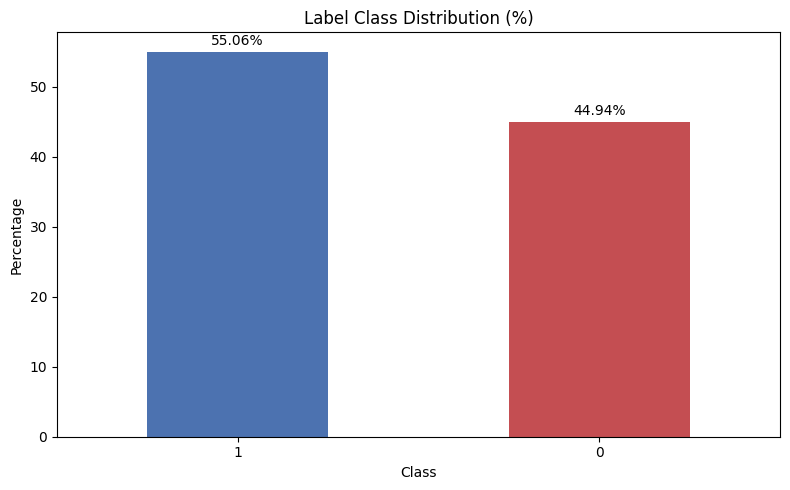

In [26]:
# Load the data
df = pd.read_csv("D:\\VS_CODE\\Python\\AI_Lab\\data\\UNSW_NB15_testing-set.csv")

# Calculate percentage of each class in Label
label_counts = df['label'].value_counts()
label_percentages = df['label'].value_counts(normalize=True) * 100

print("Class Distribution:")
print(f"\nCounts:\n{label_counts}")
print(f"\nPercentages:\n{label_percentages}")

# Visual representation
plt.figure(figsize=(8, 5))
label_percentages.plot(kind='bar', color=['#4C72B0', '#C44E52'])
plt.title('Label Class Distribution (%)')
plt.xlabel('Class')
plt.ylabel('Percentage')
plt.xticks(rotation=0)
for i, v in enumerate(label_percentages):
    plt.text(i, v + 1, f'{v:.2f}%', ha='center')
plt.tight_layout()
plt.show()